In [1]:
from pathlib import Path
import re
import pandas as pd

from ase.io import read, write
from ase.io.gaussian import read_gaussian_out

# from export_mlopt_xyz_to_total import mlopt_to_total
from lzn.data_processing.parse_dftsp_grepscf_to_df import parse_grepscf

from lzn.universal import *


### initialization

In [2]:
# # cp ml opt .xyz to opt_structure_total/
# temp1 = mlopt_to_total(8)

In [3]:
# # extract dft opt from .log to .xyz
# dft_opt_folder = Path("./tio2_ChenDixon_gjf/8_original")
# save_folder = Path("./opt_structures_total")

# for file_i in list(dft_opt_folder.glob("8*.log")):
#     # read coordination
#     print(file_i)
#     fcontent_i = open(file_i, "r")
#     atoms_i = read_gaussian_out(fcontent_i, index=-1)

#     # xyz file name
#     fname_i = file_i.stem.split("_")
#     fstructure_i = fname_i[0]
#     if fname_i[1] == "pbe":
#         fmethod_i = "pbe_def2svp"
#     else:
#         fmethod_i = "pbe0_def2svp"
#     save_name = fstructure_i + "_" + fmethod_i + ".xyz"
#     print(save_name)

#     # write xyz
#     save_path = save_folder / save_name
#     atoms_i.write(save_path, format="xyz")



In [4]:
# read all dft/tzvp sp energies to df
tio2_path = to_path("~/TiO2")
sp_E_path = tio2_path / "all_sp/all8_sp/energies.txt"

df_sp_E = parse_grepscf(sp_E_path)
df_sp_E

None


,structure,opt method,sp method,energy_au
0,8a,article_article,pbe0_def2tzvp,-7998.680535
1,8a,matpes_pbe,pbe0_def2tzvp,-7998.675239
2,8a,matpes_r2scan,pbe0_def2tzvp,-7998.684010
3,8a,mpa_mpa,pbe0_def2tzvp,-7998.675920
4,8a,omat24_omat24,pbe0_def2tzvp,-7998.675645
5,8a,omol25_low,pbe0_def2tzvp,-7998.689734
6,8a,pbe0_def2svp,pbe0_def2tzvp,-7998.689023
7,8a,pbe0_def2tzvp,pbe0_def2tzvp,-7998.690782
8,8a,pbe_def2svp,pbe0_def2tzvp,-7998.688561
9,8a,pbe_def2tzvp,pbe0_def2tzvp,-7998.683742


# sp energies

In [5]:
df_sp_E

,structure,opt method,sp method,energy_au
0,8a,article_article,pbe0_def2tzvp,-7998.680535
1,8a,matpes_pbe,pbe0_def2tzvp,-7998.675239
2,8a,matpes_r2scan,pbe0_def2tzvp,-7998.684010
3,8a,mpa_mpa,pbe0_def2tzvp,-7998.675920
4,8a,omat24_omat24,pbe0_def2tzvp,-7998.675645
5,8a,omol25_low,pbe0_def2tzvp,-7998.689734
6,8a,pbe0_def2svp,pbe0_def2tzvp,-7998.689023
7,8a,pbe0_def2tzvp,pbe0_def2tzvp,-7998.690782
8,8a,pbe_def2svp,pbe0_def2tzvp,-7998.688561
9,8a,pbe_def2tzvp,pbe0_def2tzvp,-7998.683742


In [6]:
df_pbe0sp_E = df_sp_E[df_sp_E["sp method"] == "pbe0_def2tzvp"]
df_pbesp_E = df_sp_E[df_sp_E["sp method"] == "pbe_def2tzvp"]
df_pbe0sp_E

,structure,opt method,sp method,energy_au
0,8a,article_article,pbe0_def2tzvp,-7998.680535
1,8a,matpes_pbe,pbe0_def2tzvp,-7998.675239
2,8a,matpes_r2scan,pbe0_def2tzvp,-7998.684010
3,8a,mpa_mpa,pbe0_def2tzvp,-7998.675920
4,8a,omat24_omat24,pbe0_def2tzvp,-7998.675645
5,8a,omol25_low,pbe0_def2tzvp,-7998.689734
6,8a,pbe0_def2svp,pbe0_def2tzvp,-7998.689023
7,8a,pbe0_def2tzvp,pbe0_def2tzvp,-7998.690782
8,8a,pbe_def2svp,pbe0_def2tzvp,-7998.688561
9,8a,pbe_def2tzvp,pbe0_def2tzvp,-7998.683742


In [7]:
def reformat_df(df: pd.DataFrame, ref: str):
    df = df.reset_index(drop=True)
    df = df.drop("sp method", axis=1)
    df_a = df.loc[df['structure'] == '8a', :]
    df_b = df.loc[df['structure'] == '8b', :]
    df_b = df_b.drop(["structure", "opt method"], axis=1)
    df_b = df_b.reset_index(drop=True)
    df_out = pd.concat([df_a, df_b], axis=1)
    df_out.columns.values[2] = "8a au"
    df_out.columns.values[3] = "8b au"
    df_out = df_out.drop("structure", axis=1)

    df_out.loc[:, "dE eV"] = (df_out.loc[:, "8b au"] - df_out.loc[:, "8a au"]) * hartree_to_eV

    ref_8a = df_out.loc[df_out['opt method'] == ref, "8a au"].iloc[0]
    ref_8b = df_out.loc[df_out['opt method'] == ref, "8b au"].iloc[0]
    print(ref_8a)
    print(ref_8b)
    df_out.loc[:, "8a_energy_eV_r"] = (df_out.loc[:, "8a au"] - ref_8a) * hartree_to_eV
    df_out.loc[:, "8b_energy_eV_r"] = (df_out.loc[:, "8b au"] - ref_8b) * hartree_to_eV
    df_out.loc[:, "dE_energy_eV_r"] = df_out.loc[:, "8b_energy_eV_r"] - df_out.loc[:, "8a_energy_eV_r"]

    return df_out

df_pbe0sp_E = reformat_df(df_pbe0sp_E, "pbe0_def2tzvp")


-7998.69078171
-7998.69092808


In [8]:
df_pbesp_E = reformat_df(df_pbesp_E, "pbe_def2tzvp")

-7998.78877894
-7998.78866737


In [9]:
df_pbe0sp_E

,opt method,8a au,8b au,dE eV,8a_energy_eV_r,8b_energy_eV_r,dE_energy_eV_r
0,article_article,-7998.680535,-7998.680393,0.003873,0.278819,0.286675,0.007856
1,matpes_pbe,-7998.675239,-7998.674781,0.012465,0.422945,0.439393,0.016448
2,matpes_r2scan,-7998.684010,-7998.683693,0.008611,0.184276,0.196870,0.012594
3,mpa_mpa,-7998.675920,-7998.675791,0.003506,0.404406,0.411895,0.007489
4,omat24_omat24,-7998.675645,-7998.675534,0.003022,0.411893,0.418897,0.007004
5,omol25_low,-7998.689734,-7998.689868,-0.003636,0.028503,0.028851,0.000347
6,pbe0_def2svp,-7998.689023,-7998.689135,-0.003070,0.047865,0.048779,0.000913
7,pbe0_def2tzvp,-7998.690782,-7998.690928,-0.003983,0.000000,0.000000,0.000000
8,pbe_def2svp,-7998.688561,-7998.688511,0.001359,0.060437,0.065779,0.005342
9,pbe_def2tzvp,-7998.683742,-7998.683643,0.002686,0.191571,0.198240,0.006669


In [10]:
df_pbesp_E

,opt method,8a au,8b au,dE eV,8a_energy_eV_r,8b_energy_eV_r,dE_energy_eV_r
0,article_article,-7998.787842,-7998.787465,0.010268,0.025500,0.032732,0.007232
1,matpes_pbe,-7998.786960,-7998.786760,0.005431,0.049507,0.051901,0.002395
2,matpes_r2scan,-7998.788403,-7998.788164,0.006515,0.010217,0.013696,0.003480
3,mpa_mpa,-7998.787075,-7998.787039,0.000981,0.046364,0.044308,-0.002055
4,omat24_omat24,-7998.787062,-7998.786959,0.002797,0.046715,0.046475,-0.000239
5,omol25_low,-7998.784245,-7998.784818,-0.015580,0.123372,0.104756,-0.018616
6,pbe0_def2svp,-7998.774426,-7998.773949,0.012980,0.390555,0.400498,0.009944
7,pbe0_def2tzvp,-7998.782162,-7998.781819,0.009355,0.180044,0.186363,0.006319
8,pbe_def2svp,-7998.787115,-7998.786961,0.004169,0.045287,0.046420,0.001133
9,pbe_def2tzvp,-7998.788779,-7998.788667,0.003036,0.000000,0.000000,0.000000


# Processing

In [11]:
general_save = to_path("~/organized/901_data")
df_pbe0sp_E.to_csv(general_save / "8ab_all_pbe0sp.csv")
df_pbesp_E.to_csv(general_save / "8ab_all_pbesp.csv")

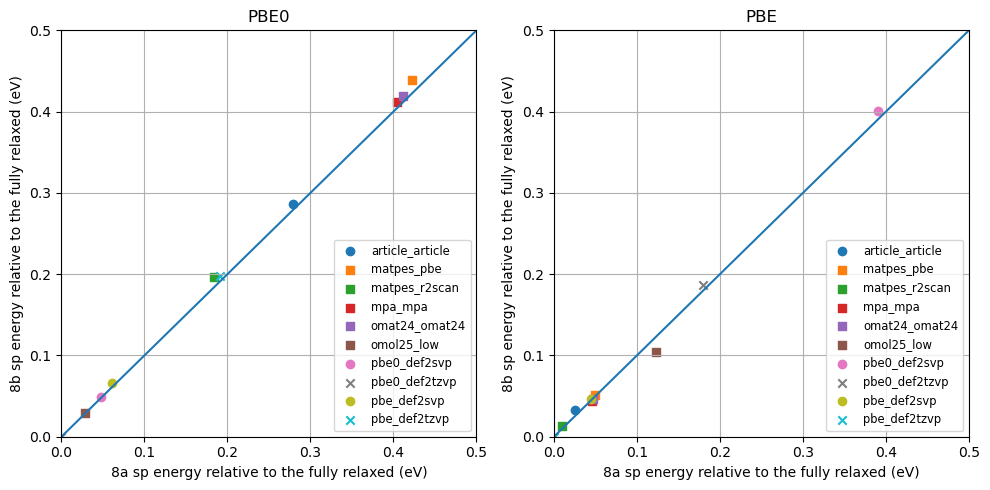

In [12]:
from matplotlib import pyplot as plt

fig1 = plt.figure(1, figsize = (10,5))
gs = fig1.add_gridspec(1,2)

df_l = [df_pbe0sp_E, df_pbesp_E]
title_l = ["PBE0", "PBE"]

for i, df_ in enumerate(df_l):
    grid_name = fig1.add_subplot(gs[0, i])
    grid_name.set_title(title_l[i])

    for j, method_name in enumerate(df_["opt method"]):
        if j > 0 and j < 6:
            marker = "s"
        else:
            marker = "o"
        if method_name == "pbe0_def2tzvp" or method_name == "pbe_def2tzvp":
            marker = "P"
        grid_name.scatter(df_["8a_energy_eV_r"][j], df_["8b_energy_eV_r"][j], label=method_name, marker=marker)
    grid_name.plot([0., 1.], [0., 1.], "-")

    grid_name.legend(loc="lower right", fontsize="small")
    grid_name.set_xlim(0., 0.5)
    grid_name.set_ylim(0., 0.5)
    grid_name.set_xlabel("8a sp energy relative to the fully relaxed (eV)")
    grid_name.set_ylabel("8b sp energy relative to the fully relaxed (eV)")
    grid_name.grid(True)

fig1.tight_layout()
plt.show()

fig1.savefig(general_save / "8ab_sp.pdf")

# Combine 5ab and 8ab

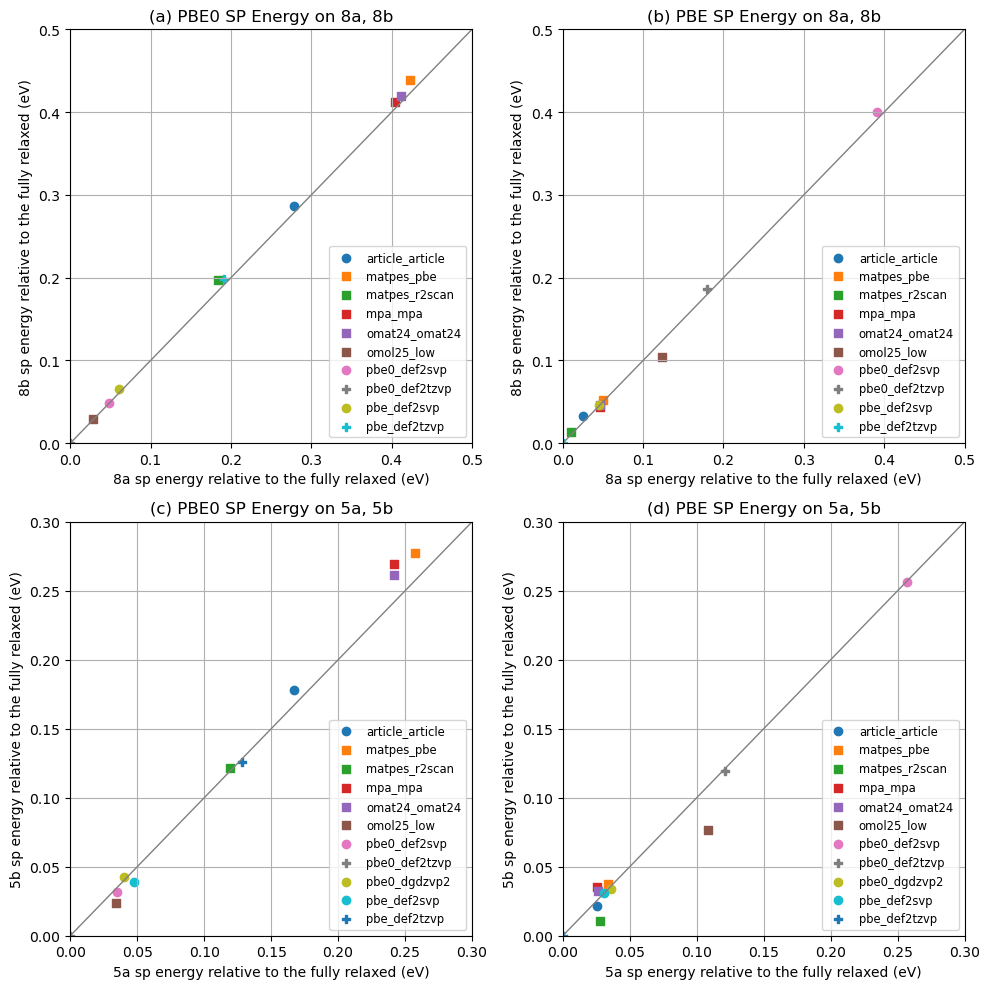

In [21]:
fig1 = plt.figure(1, figsize = (10,10))
gs = fig1.add_gridspec(2,2)

df_l = [df_pbe0sp_E, df_pbesp_E,
        pd.read_csv(general_save / "5ab_all_pbe0sp.csv"),
        pd.read_csv(general_save / "5ab_all_pbesp.csv")]
title_l = ["(a) PBE0 SP Energy on 8a, 8b", "(b) PBE SP Energy on 8a, 8b",
           "(c) PBE0 SP Energy on 5a, 5b", "(d) PBE SP Energy on 5a, 5b"]

for i, df_ in enumerate(df_l):
    ix = i
    iy = 0
    plot_range = 0.5
    n = 8
    if i > 1:
        iy = 1
        ix = i - 2
        plot_range = 0.3
        n = 5
    grid_name = fig1.add_subplot(gs[iy, ix])
    grid_name.set_title(title_l[i])

    grid_name.plot([0., 1.], [0., 1.], "-", lw = 1, color = "gray")
    for j, method_name in enumerate(df_["opt method"]):
        if j > 0 and j < 6:
            marker = "s"
        else:
            marker = "o"
        if method_name == "pbe0_def2tzvp" or method_name == "pbe_def2tzvp":
            marker = "P"
        grid_name.scatter(df_[f"{n}a_energy_eV_r"][j], df_[f"{n}b_energy_eV_r"][j], label=method_name, marker=marker)

    grid_name.legend(loc="lower right", fontsize="small")
    grid_name.set_xlim(0., plot_range)
    grid_name.set_ylim(0., plot_range)
    grid_name.set_xlabel(f"{n}a sp energy relative to the fully relaxed (eV)")
    grid_name.set_ylabel(f"{n}b sp energy relative to the fully relaxed (eV)")
    grid_name.grid(True)

fig1.tight_layout()
plt.show()

fig1.savefig(general_save / "58ab_sp.pdf")